In [9]:
import sys
sys.path.insert(0, "../src/fg_removal_pipe")  # add Folder_2 path to search list
import diff_removal as bss
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np


In [10]:
base = '/home/ppxjf3/repos/Foreground_Removal_Pipeline/'

fits_path = base + 'data/natural_4_fg_removal-image.fits'

hdul = fits.open(fits_path)

img = np.squeeze(hdul[0].data)
hdul.info()
hdul.close()

Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/natural_4_fg_removal-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   


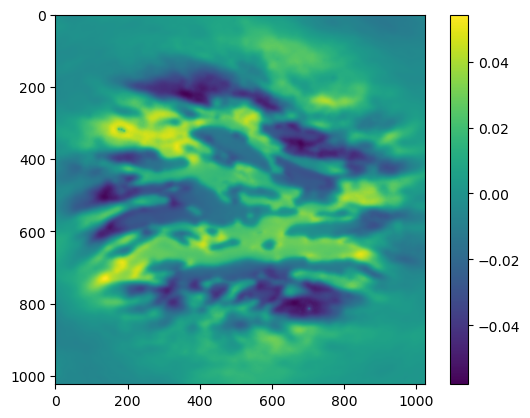

In [14]:
#look at image
plt.imshow(img)
plt.colorbar()

In [17]:
from sklearn.decomposition import FastICA


f_ica = FastICA(n_components=4)
#generate the 4 components
S = f_ica.fit_transform(img)

#get mixing matrix
A = f_ica.mixing_
    
#make model
model_fICA = (np.matmul(A,S.T).T)
    
#get resids
resids_fICA = img - model_fICA #residuals 
    